In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

In [212]:
npz = np.load('../benchmark/half_cheetah/train.npz')
s, fail = npz['states'], npz['fail']

succ = fail == 0

In [213]:
pf = PolynomialFeatures(degree = 3)

In [215]:
succ_states = s[succ].reshape(-1, 17)

In [216]:
V = pf.fit_transform(succ_states)
V.shape

(710000, 1140)

In [217]:
V.shape

(710000, 1140)

In [218]:
M = V.T @ V / len(succ_states)

In [219]:
eigvals, eigvec = np.linalg.eig(M)

In [220]:
eigvals.min()

8.883038258751687e-09

In [221]:
p = eigvec[:, -1]

In [224]:
(M @ p).max()

1.0160802289742044e-07

In [225]:
def q(x):
    return pf.fit_transform(x) @ p

In [226]:
max = np.quantile(np.abs(q(succ_states)), 0.99)
max

0.0020095335920504364

In [227]:
fail

array([243,   0, 523, 119,  15,   0,   0,  76,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0, 128, 111,   0,   0,
       299,   9,   0,   0,   0,   0,   0,   0, 549,  85, 484,   0, 285,
         0, 984,   0,   0, 174,   0, 961,  92,   0, 116,   0,   0,   0,
         0, 958,   0, 152,   0, 281,   0,   0,   0,   0,   8, 283, 588,
         0,   0,   0,   0, 257,   0,   0,   0,   0,   0,   0,   0,   0,
         0,  92, 213,   0, 794,   0,   0,   0,   0,  75, 135, 436,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0, 171,   0,   0,   0,
         0,   0, 354, 101, 547,   0,   0,   0,   0,   0, 128,  81, 117,
         0,   0,   0, 121, 276, 879,   0,   0,   0,   0, 723,   0,   0,
         0, 487, 308,   0, 548, 370, 304, 300, 780,   0, 517,   0,   0,
         0,   0,   0,   0,  58,   0,   0,   0,   0,   0,   0,   0,   0,
       143,   0,   0,   0,   0, 387, 662,   0,   0, 153,   0,   0,   0,
         0,   0,   0,   0, 108, 194, 696, 480,   0, 430,   0,   

(-0.0020095335920504364, 0.0020095335920504364)

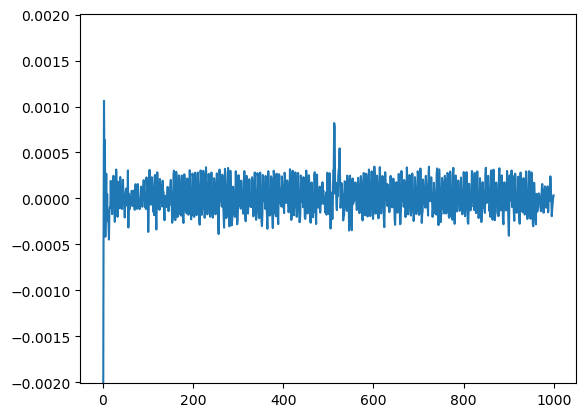

In [244]:
i = 3
plt.plot(q(s[succ][i]))
#plt.axvline(fail[~succ][i], color='red')
plt.ylim(-max, max)